# Customer Churn Prediction

## Project Overview

Customer churn is one of the most important business problems for telecom companies.  
The goal of this project is to analyze customer behavior and build a machine learning model that predicts whether a customer is likely to leave the company.

This project includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Model Building
- Model Evaluation
- Business Recommendations

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.max_columns', None)

## 1. Load Dataset

The dataset used in this project is the Telco Customer Churn dataset.  
It contains customer demographic information, account details, services used, and whether the customer churned or not.

In [2]:
# Load Dataset

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Overview

In [3]:
# Dataset Shape

df.shape

(7043, 21)

In [4]:
# Dataset Columns

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Summary Statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Data Quality Check

In this step, we check missing values, duplicated records, and data type issues.

In [7]:
# Missing Values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
# Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [9]:
# Check data types

df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### TotalCharges Data Type Issue

The `TotalCharges` column should be numeric, but it may be stored as object due to empty or invalid values.

In [10]:
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
# Fill missing TotalCharges values with the median

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['TotalCharges'].isnull().sum()

np.int64(0)

## 4. Target Variable Analysis

The target variable is `Churn`, which shows whether the customer left the company or not.

In [12]:
# Churn Distribution

df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
# Churn Percentage

df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


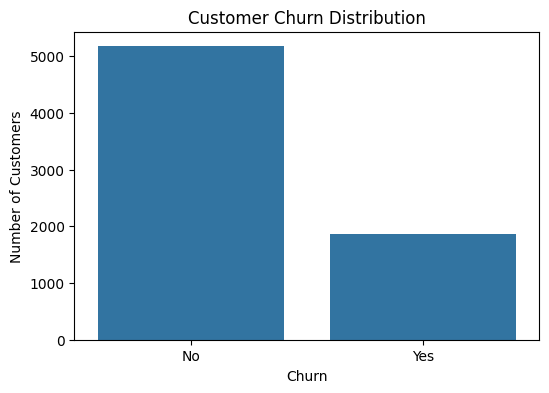

In [14]:
# Churn Count Plot

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

### Insight

The dataset is imbalanced because the number of customers who did not churn is higher than the number of customers who churned.  
Because of this, Accuracy alone may not be enough, and we should also evaluate Precision, Recall, and F1-score.

## 5. Exploratory Data Analysis (EDA)

### Churn by Contract Type

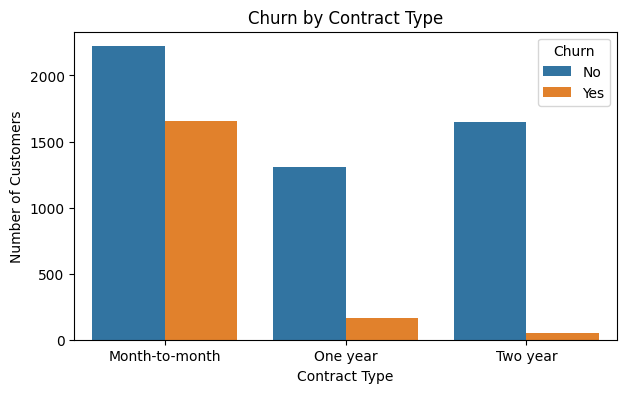

In [15]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

### Insight

Customers with month-to-month contracts are more likely to churn compared to customers with one-year or two-year contracts.

### Churn by Internet Service

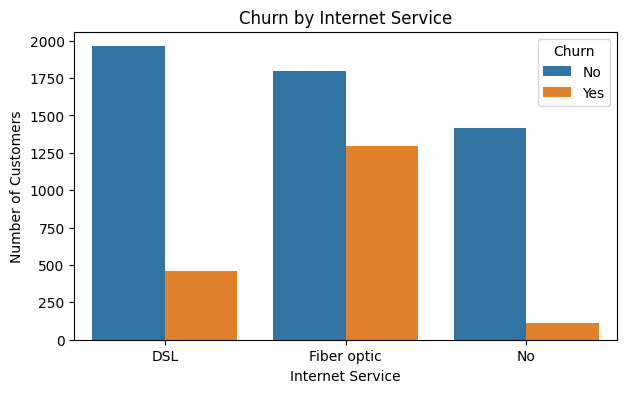

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

### Churn by Payment Method

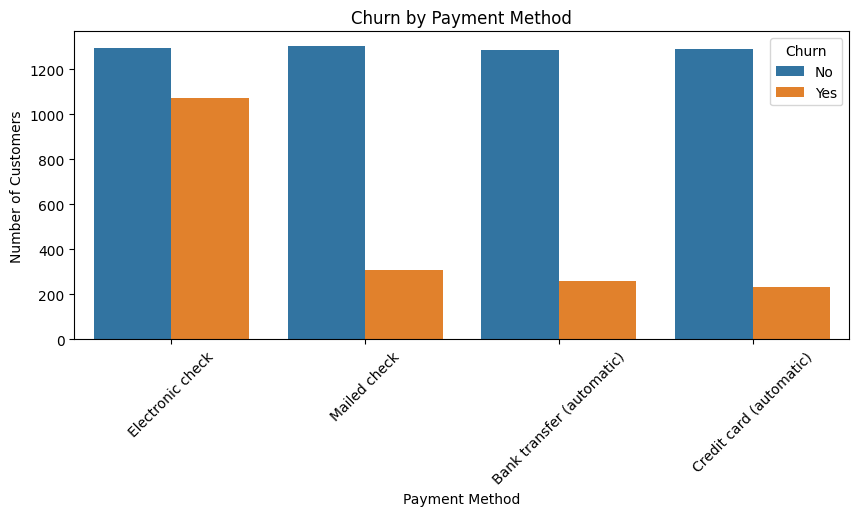

In [17]:
plt.figure(figsize=(10,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.show()

### Monthly Charges Distribution

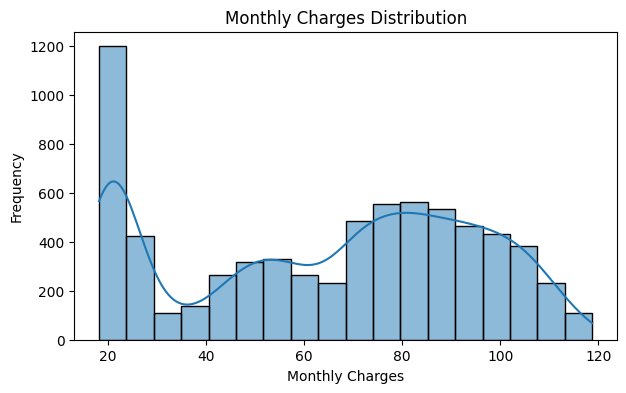

In [18]:
plt.figure(figsize=(7,4))
sns.histplot(df['MonthlyCharges'], kde=True)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.show()

### Monthly Charges by Churn

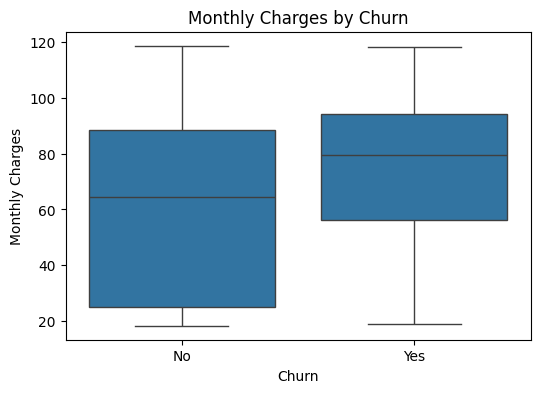

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

### Tenure by Churn

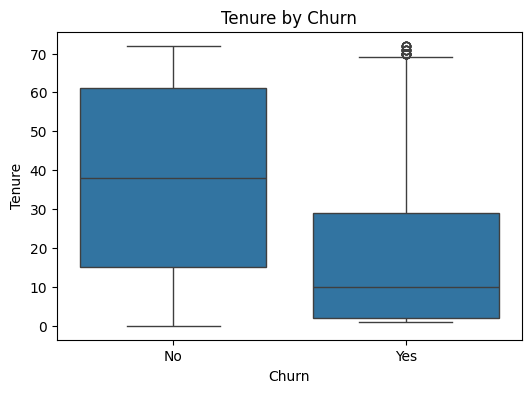

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')

plt.show()

### Insight

Customers who churn often have shorter tenure.  
This suggests that new customers may need more engagement and retention strategies.

## 6. Data Preprocessing

Before building the model, we need to prepare the data:
- Drop customerID because it is only an identifier.
- Convert categorical variables into numeric values.
- Convert the target column into binary values.

In [21]:
# Drop customerID column

df_model = df.drop('customerID', axis=1)

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
# Convert target variable

df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})

df_model['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [23]:
# One-hot encode categorical variables

df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [24]:
# Check encoded dataset shape

df_encoded.shape

(7043, 31)

## 7. Correlation Analysis

In [25]:
# Correlation with target variable

churn_correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)

churn_correlation.head(10)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService_Yes,0.011942


In [26]:
# Top negative correlations

churn_correlation.tail(10)

,Churn
TotalCharges,-0.199037
InternetService_No,-0.227890
StreamingTV_No internet service,-0.227890
OnlineSecurity_No internet service,-0.227890
OnlineBackup_No internet service,-0.227890
DeviceProtection_No internet service,-0.227890
StreamingMovies_No internet service,-0.227890
TechSupport_No internet service,-0.227890
Contract_Two year,-0.302253
tenure,-0.352229


## 8. Model Building

This is a binary classification problem because the target variable has two classes:
- 0 = No Churn
- 1 = Churn

Logistic Regression is used as a baseline classification model.

In [27]:
# Split features and target

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X.shape, y.shape

((7043, 30), (7043,))

In [28]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5634, 30), (1409, 30))

In [34]:
# Train Logistic Regression Model

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [35]:
# Make Predictions

y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

## 9. Model Evaluation

Since this is a classification problem, we evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [36]:
# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.8062
Precision: 0.6593
Recall: 0.5588
F1 Score: 0.6049


In [37]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



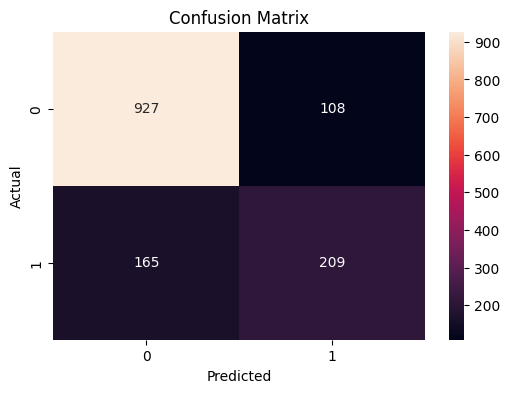

In [38]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Evaluation Interpretation

Accuracy shows the overall correctness of the model.  
Precision shows how many customers predicted as churn actually churned.  
Recall shows how many actual churn customers were correctly detected.  
F1-score balances Precision and Recall.

## 10. Business Insights

Based on the analysis:

1. Customers with month-to-month contracts are more likely to churn.
2. Customers with shorter tenure have higher churn risk.
3. Payment method and internet service type appear to be related to churn behavior.
4. Churn prediction should not rely only on Accuracy because the dataset is imbalanced.

## 11. Business Recommendations

1. Offer retention campaigns for month-to-month customers.
2. Create onboarding programs for new customers with low tenure.
3. Review pricing strategies for customers with high monthly charges.
4. Encourage customers to move to longer-term contracts.
5. Use churn prediction models to identify at-risk customers early.

## 12. Conclusion

This project demonstrated how machine learning can support customer retention strategies.  
By combining EDA, preprocessing, Logistic Regression, and evaluation metrics, we can identify patterns related to churn and build a baseline predictive model.